<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fpranathi_kolla/weeks/week_05/05_2D_Wings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 05: The 2D Wing — Connecting Shape to Amplitude

In the previous two weeks you built a statistical description of the *shape* of a solar butterfly wing: the mean emergence latitude drifts equatorward following a universal exponential, and the spread σ around that mean follows a piecewise-linear function of mean latitude μ. What the model is still missing is any connection to how *strong* a cycle is. A weak cycle and a strong cycle can share the same geometric skeleton — what distinguishes them is the overall level of activity.

This notebook completes the picture in two stages. **Sections 1–5** recap and finalize the shape model from Week 04, producing its key result: a universal equatorward line in σ(μ) space that is shared by every hemisphere-cycle, plus a per-cycle poleward slope that captures each cycle's individual character. **Tasks 17–20** ask you to bring in a new ingredient — total sunspot area — and find quantitative relationships between cycle amplitude and the three shape parameters, ultimately synthesizing a full 2D butterfly wing from a single input number.

**By the end of this notebook you should be able to:**
- Explain what the universal equatorward line in σ(μ) space represents physically.
- Compute the peak amplitude of each hemispheric solar cycle from the sunspot area record.
- Describe quantitative relationships between cycle amplitude and the wing shape parameters (μ₀, μ_peak, m_i).
- Generate a synthetic butterfly wing for a chosen cycle and compare it to real data.

In [1]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 1) Load data

We work with the same composite catalog of daily sunspot group measurements used in Weeks 03 and 04. Each row records one sunspot group observation: its date, heliographic latitude, and corrected area in millionths of a solar hemisphere (MSH). We add convenience columns for hemisphere, absolute latitude, and decimal year that all subsequent sections depend on.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit, minimize_scalar, minimize

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)
df = df[df["latitude"].notna()].copy()

df["hemisphere"]   = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
df["abs_latitude"] = df["latitude"].abs()
df["year"] = df["date"].dt.year
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

df.head()

/tmp/ipykernel_6383/1082563259.py:11: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_6383/1082563259.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,hour,minute,second,latitude,longitude,correctedArea,CAUnc,uniqueID,CYCLE,survey,hemisphere,abs_latitude,year,decimal_year
0,1825-11-05,12.0,30.0,0.0,-1.2,331.8,2120.0,570.0,SC_101,NaN,1.0,south,1.2,1825,1825.845996
3,1825-11-08,12.0,0.0,0.0,-17.9,321.8,670.0,190.0,SC_102,NaN,1.0,south,17.9,1825,1825.854209
4,1825-11-09,14.0,45.0,0.0,-14.6,320.7,500.0,150.0,SC_102,NaN,1.0,south,14.6,1825,1825.856947
5,1825-11-10,12.0,0.0,0.0,-27.4,318.1,520.0,150.0,SC_103,NaN,1.0,south,27.4,1825,1825.859685
6,1825-11-11,12.0,0.0,0.0,-26.3,320.8,470.0,140.0,SC_103,NaN,1.0,south,26.3,1825,1825.862423


## 2) Standardize time: align cycles at the 15° crossing (τ)

Solar cycles don't start on the same calendar date and don't last the same length of time, so we can't compare them on a shared time axis without first choosing a common reference point. The anchor we use is the moment when the **yearly mean absolute emergence latitude crosses 15° on its way equatorward** — a latitude that falls reliably in the well-observed middle of every cycle.

For each (cycle, hemisphere) pair we find that crossing by linear interpolation between the last year the mean sits above 15° and the first year it falls below. The shifted coordinate **τ = decimal\_year − t₀** is in physical units (years) and places all cycles on the same footing regardless of when they actually occurred.

In [3]:
t0_lookup = {}
for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years, means = yearly_mean.index.values, yearly_mean.values
    below = means < 15.0
    if not below.any() or below.all():
        continue
    idx1 = np.argmax(below)
    if idx1 == 0:
        continue
    y0, mu0 = years[idx1 - 1], means[idx1 - 1]
    y1, mu1 = years[idx1],     means[idx1]
    t0_lookup[(cyc, hemi)] = y0 + (15.0 - mu0) / (mu1 - mu0)

df["t0"]  = df.apply(lambda r: t0_lookup.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

## 3) Fit a universal mean path μ(τ) and refine the time origin

The equatorward drift of the mean emergence latitude follows an exponential decay:

$$\mu(\tau) = a \, e^{-\tau / b}$$

where **a** is the mean latitude at τ = 0 and **b** is the e-folding timescale — the number of years it takes the mean to drop by a factor of e ≈ 2.7. In Week 04 you found that the best-fit (a, b) is nearly the same for every cycle, so here we fit it once, globally, by pooling binned (τ, μ) measurements from all hemisphere-cycles.

With the universal (a, b) in hand we can refine each cycle's t₀: a small time shift Δt is found for each hemisphere-cycle that minimises its residuals against the common template. The refined coordinate **τ_refined** gives a tighter alignment than the raw 15° crossing, because it uses the full shape of the wing rather than a single crossing point.

In [4]:
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

N_BINS_13   = 20
cycles_13   = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
cmap_13     = cm.get_cmap("tab20", len(cycles_13))
cyc_idx_13  = {c: i for i, c in enumerate(cycles_13)}

all_tau_bins, all_mu_bins = [], []
hemicycle_bins_13 = {}

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_13 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bt, bm = [], []
        for i in range(N_BINS_13):
            lats_bin = df_sel.loc[
                (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, _ = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f)
        if len(bt) < 5:
            continue
        bt = np.array(bt); bm = np.array(bm)
        hemicycle_bins_13[(cyc, hemi)] = (bt, bm)
        all_tau_bins.extend(bt); all_mu_bins.extend(bm)

popt_global, _ = curve_fit(exp_decay, all_tau_bins, all_mu_bins, p0=[15.0, 5.0])
a_mu_univ, b_mu_univ = popt_global
print(f"Universal μ(τ):  a = {a_mu_univ:.2f}°   b = {b_mu_univ:.2f} yr")

# Refine t₀ per hemisphere-cycle
t0_refined = {}
for (cyc, hemi), (bt, bm) in hemicycle_bins_13.items():
    def _res(dt, _bt=bt, _bm=bm):
        return np.sum((_bm - exp_decay(_bt - dt, a_mu_univ, b_mu_univ)) ** 2)
    res = minimize_scalar(_res, bounds=(-4, 4), method="bounded")
    t0_refined[(cyc, hemi)] = t0_lookup[(cyc, hemi)] + res.x

df["t0_refined"]  = df.apply(lambda r: t0_refined.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau_refined"] = df["decimal_year"] - df["t0_refined"]

/tmp/ipykernel_6383/1516041124.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_13     = cm.get_cmap("tab20", len(cycles_13))


Universal μ(τ):  a = 16.45°   b = 8.14 yr


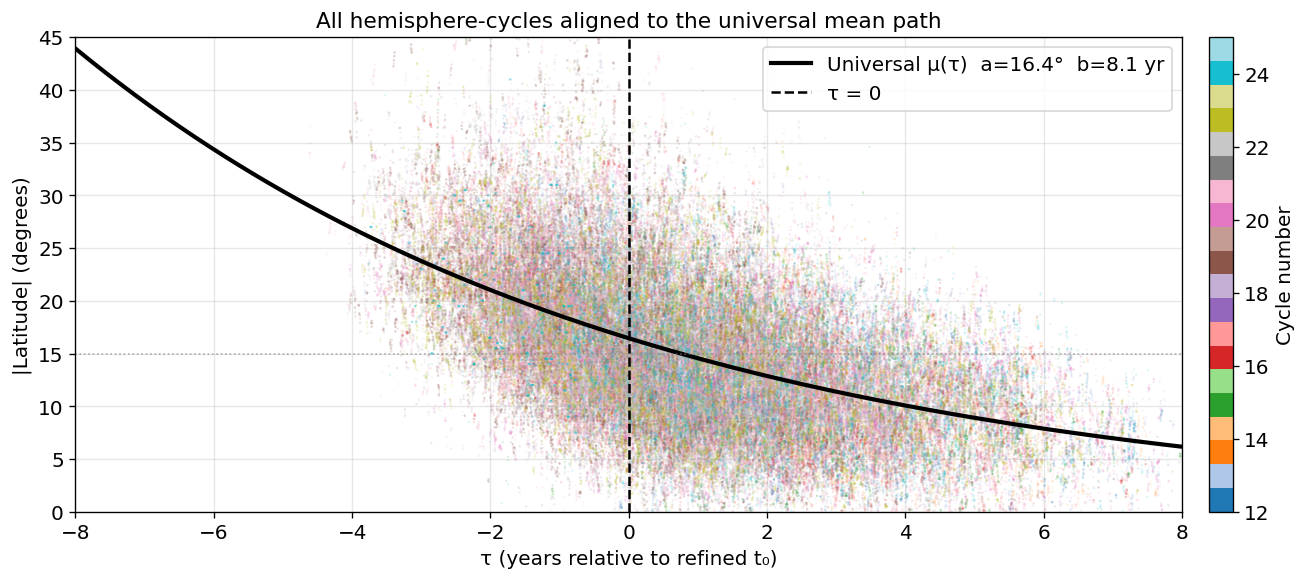

In [5]:
TAU_GRID_13 = np.linspace(-8, 8, 300)

# Plot 1: All hemisphere-cycles aligned to the universal mean path
fig1, ax1 = plt.subplots(figsize=(12, 5))
for (cyc, hemi) in hemicycle_bins_13:
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    grp  = df[mask]
    ax1.scatter(grp["tau_refined"], grp["abs_latitude"],
                s=2, color=cmap_13(cyc_idx_13[cyc]), alpha=0.15, edgecolors="none")
ax1.plot(TAU_GRID_13, exp_decay(TAU_GRID_13, a_mu_univ, b_mu_univ),
         color="black", linewidth=2.5,
         label=f"Universal μ(τ)  a={a_mu_univ:.1f}°  b={b_mu_univ:.1f} yr")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to refined t₀)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles aligned to the universal mean path")
ax1.set_ylim(0, 45); ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right")
sm1 = plt.cm.ScalarMappable(cmap="tab20",
                              norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm1.set_array([])
fig1.colorbar(sm1, ax=ax1, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()


## 4) Model σ(μ): spread as a function of mean latitude

Rather than tracking the spread σ as a function of time, we describe it as a function of the **current mean emergence latitude** μ. This is more natural physically: two cycles at the same latitude should have similar spreads regardless of their absolute timing, because the spread is determined by the state of the dynamo, not by the calendar.

The spread is not monotonic in μ. At high latitudes (early in the cycle) there are few sunspots so the spread appears narrow; at low latitudes (late in the cycle) the active zone has collapsed toward the equator and is narrow again. The maximum spread occurs somewhere in between, at a characteristic mid-cycle latitude μ_peak. This bell-shaped behaviour in μ-space is captured by a **split Gaussian**:

$$\sigma(\mu) = A \exp\!\left(-\frac{(\mu - \mu_{\mathrm{peak}})^2}{2 s_{L,R}^2}\right)$$

where $s_L$ governs the poleward side (large μ, early cycle) and $s_R$ governs the equatorward side (small μ, late cycle). When $s_L \neq s_R$ the envelope is asymmetric — which is what the data show.

In [6]:
def split_normal_mu(mu, A, mu_peak, s_L, s_R):
    return np.where(
        mu >= mu_peak,
        A * np.exp(-0.5 * ((mu - mu_peak) / s_L) ** 2),
        A * np.exp(-0.5 * ((mu - mu_peak) / s_R) ** 2),
    )

N_BINS_15 = 20
MU_GRID   = np.linspace(2, 42, 300)
results_15 = []

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_refined:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_15 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bm_list, bs_list = [], []
        for i in range(N_BINS_15):
            lats_bin = df_sel.loc[
                (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bm_list.append(mu_f); bs_list.append(sigma_f)
        if len(bm_list) < 5:
            continue
        bm_arr = np.array(bm_list); bs_arr = np.array(bs_list)
        sidx = np.argsort(bm_arr)
        bm_arr, bs_arr = bm_arr[sidx], bs_arr[sidx]
        try:
            p0 = [bs_arr.max(), bm_arr[np.argmax(bs_arr)], 5.0, 4.0]
            popt, _ = curve_fit(split_normal_mu, bm_arr, bs_arr, p0=p0, maxfev=10_000)
            A_f, mu_peak_f, sL_f, sR_f = popt
        except RuntimeError:
            continue
        if not (0.5 < A_f < 20 and 2 < mu_peak_f < 38 and 0.5 < sL_f < 20 and 0.5 < sR_f < 20):
            continue
        results_15.append(dict(
            cycle=cyc, hemisphere=hemi,
            A=A_f, mu_peak=mu_peak_f, sL=sL_f, sR=sR_f,
            sigma_curve=split_normal_mu(MU_GRID, A_f, mu_peak_f, sL_f, sR_f),
            bin_mu=bm_arr, bin_sigma=bs_arr,
        ))

print(f"Fitted {len(results_15)} hemisphere-cycles.")

Fitted 19 hemisphere-cycles.


## 5) Universal piecewise-linear envelope

The key insight from Week 04 is that the equatorward half of every σ(μ) curve — the side where spots are migrating toward the equator — falls on **the same straight line** regardless of which cycle you look at. This universality tells us something deep: the process that narrows the active zone as the cycle approaches minimum is the same in every cycle. One slope and one intercept describe it for all of them.

The poleward half, by contrast, is cycle-specific: stronger cycles detach from the shared line at a higher latitude and descend more steeply. We encode this with a piecewise-linear model fitted *jointly* across all hemisphere-cycles:

$$\sigma(\mu) = \begin{cases} m_{\text{shared}}\,\mu + b_{\text{shared}} & \mu \le \mu_{\text{peak},i} \quad \text{(universal — same for all cycles)} \\ m_i\,\mu + b_i & \mu > \mu_{\text{peak},i} \quad \text{(per-cycle)} \end{cases}$$

Continuity at the detachment latitude $\mu_{\text{peak},i}$ determines $b_i$ automatically, so the model needs only two universal numbers $(m_{\text{shared}},\, b_{\text{shared}})$ and two per-cycle numbers $(\mu_{\text{peak},i},\, m_i)$ to fully describe each wing's spread profile. In the exercises below you will connect those per-cycle numbers to the overall strength of each cycle.

Universal line:  σ(μ) = 0.4076·μ + 0.2507
Zero crossing at μ = -0.62°
RMSE — split-normal independent : 0.738°
RMSE — piecewise-linear joint   : 0.805°  (+9.1%)


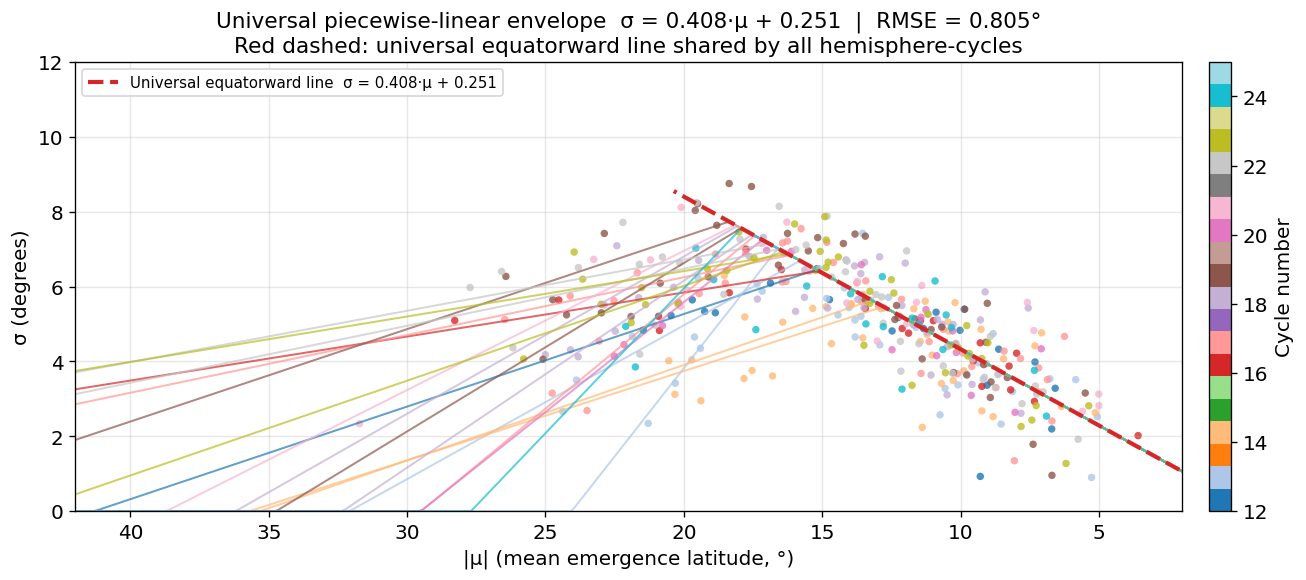


Per-cycle variability:
  μ_peak : 16.50° ± 1.52°  ← detachment latitude
  σ_peak : 6.98° ± 0.62°  ← derived amplitude
  m_i  : -0.3678 ± 0.2260  ← per-cycle poleward slope


In [7]:
def piecewise_linear_wing(mu, m_shared, b_shared, mu_peak, m_i):
    """Universal equatorward line + per-cycle poleward line, joined continuously at mu_peak."""
    sigma_peak = m_shared * mu_peak + b_shared
    b_per = sigma_peak - m_i * mu_peak
    return np.clip(
        np.where(mu <= mu_peak, m_shared * mu + b_shared, m_i * mu + b_per),
        0.0, None
    )

# Bootstrap: fit the shared equatorward line from pooled equatorward-side points
eq_mu, eq_sigma = [], []
for r in results_15:
    mask = r["bin_mu"] <= r["mu_peak"]
    eq_mu.extend(r["bin_mu"][mask]); eq_sigma.extend(r["bin_sigma"][mask])
m_init, b_init = np.polyfit(eq_mu, eq_sigma, 1)
m_i_init = np.mean([-r["A"] / (2 * max(r["sL"], 1.0)) for r in results_15])

# Joint L-BFGS-B optimisation
n_hc = len(results_15)

def residuals_pl(x):
    m_sh, b_sh = x[0], x[1]
    return sum(
        np.sum((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], m_sh, b_sh, x[2 + 2*i], x[3 + 2*i])) ** 2)
        for i, r in enumerate(results_15)
    )

x0 = np.array([m_init, b_init] + [val for r in results_15
                                   for val in (r["mu_peak"], m_i_init)])
bounds = list(zip(
    [0.0, -5.0] + [2.0, -5.0] * n_hc,
    [2.0,  5.0] + [38.0, 0.0] * n_hc,
))
opt = minimize(residuals_pl, x0, method="L-BFGS-B", bounds=bounds)

m_shared_fit, b_shared_fit = opt.x[0], opt.x[1]
print(f"Universal line:  σ(μ) = {m_shared_fit:.4f}·μ + {b_shared_fit:.4f}")
print(f"Zero crossing at μ = {-b_shared_fit / m_shared_fit:.2f}°")

# Reconstruct per-cycle fitted curves
MU_GRID_PL = np.linspace(2, 42, 300)
results_pl = []
for i, r in enumerate(results_15):
    mu_peak_i    = opt.x[2 + 2*i]
    m_i          = opt.x[3 + 2*i]
    sigma_peak_i = m_shared_fit * mu_peak_i + b_shared_fit
    results_pl.append(dict(
        cycle=r["cycle"], hemisphere=r["hemisphere"],
        m_shared=m_shared_fit, b_shared=b_shared_fit,
        mu_peak=mu_peak_i, m_i=m_i, sigma_peak=sigma_peak_i,
        sigma_curve=piecewise_linear_wing(
            MU_GRID_PL, m_shared_fit, b_shared_fit, mu_peak_i, m_i),
        bin_mu=r["bin_mu"], bin_sigma=r["bin_sigma"],
    ))

# RMSE comparison
def rmse_sn(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - split_normal_mu(
            r["bin_mu"], r["A"], r["mu_peak"], r["sL"], r["sR"])) ** 2)
        for r in res_list
    ]))

def rmse_pl(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], r["m_shared"], r["b_shared"], r["mu_peak"], r["m_i"])) ** 2)
        for r in res_list
    ]))

rmse_15 = rmse_sn(results_15)
rmse_16 = rmse_pl(results_pl)
print(f"RMSE — split-normal independent : {rmse_15:.3f}°")
print(f"RMSE — piecewise-linear joint   : {rmse_16:.3f}°  ({(rmse_16 - rmse_15)/rmse_15*100:+.1f}%)")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for r in results_pl:
    c = cmap_13(cyc_idx_13.get(r["cycle"], 0))
    ax.scatter(r["bin_mu"], r["bin_sigma"], s=20, color=c,
               alpha=0.8, edgecolors="none", zorder=1)
    ax.plot(MU_GRID_PL, r["sigma_curve"], color=c,
            linewidth=1.2, alpha=0.7, zorder=2)

mu_eq = np.linspace(0, max(r["mu_peak"] for r in results_pl) + 2, 200)
ax.plot(mu_eq, np.clip(m_shared_fit * mu_eq + b_shared_fit, 0, None),
        color="tab:red", linewidth=2.5, linestyle="--",
        label=f"Universal equatorward line  σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}",
        zorder=5)

ax.invert_xaxis()
ax.set_xlim(42, 2)
ax.set_ylim(0, 12)
ax.set_xlabel("|μ| (mean emergence latitude, °)")
ax.set_ylabel("σ (degrees)")
ax.set_title(
    f"Universal piecewise-linear envelope  "
    f"σ = {m_shared_fit:.3f}·μ + {b_shared_fit:.3f}  |  RMSE = {rmse_16:.3f}°\n"
    "Red dashed: universal equatorward line shared by all hemisphere-cycles"
)
ax.legend(loc="upper left", fontsize=9)

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_13), vmax=max(cycles_13)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

# Numeric summary
mu_peaks  = [r["mu_peak"]    for r in results_pl]
sig_peaks = [r["sigma_peak"] for r in results_pl]
m_is    = [r["m_i"]      for r in results_pl]
print(f"\nPer-cycle variability:")
print(f"  μ_peak : {np.mean(mu_peaks):.2f}° ± {np.std(mu_peaks):.2f}°  ← detachment latitude")
print(f"  σ_peak : {np.mean(sig_peaks):.2f}° ± {np.std(sig_peaks):.2f}°  ← derived amplitude")
print(f"  m_i  : {np.mean(m_is):.4f} ± {np.std(m_is):.4f}  ← per-cycle poleward slope")

---
## Week 05 Exercises: From Wing Shape to a Full Synthetic Cycle

Sections 1–5 give you the geometric skeleton of a butterfly wing. The exercises below ask you to attach one more piece: the **amplitude** of the solar cycle. A cycle's amplitude tells you how active it was — how many sunspots appeared, how large they were, how long the active zone persisted. Once you can predict the wing's shape parameters from its amplitude, you can synthesize a complete 2D wing from a single number.

The four tasks build up to that synthesis step by step.

---

## Task 17 — Solar Cycle Amplitude from Total Sunspot Area

The standard proxy for solar cycle strength is the **total daily corrected sunspot area** — the sum of all individual sunspot group areas on a given day, measured in millionths of a solar hemisphere (MSH). Plotted over time, this quantity rises and falls with each ~11-year cycle, with strong cycles reaching much higher peaks than weak ones.

Raw daily values are noisy (individual sunspot groups appear and disappear), so we smooth with a rolling average before looking for cycle peaks.

**Tasks:**
- For each hemisphere separately, compute the total daily corrected area. Include only sunspot groups with a corrected area **greater than 50 MSH** — smaller features are at the noise floor of the older observations.
- Apply rolling averages with windows of **3, 6, 12, and 24 months**. Plot all four smoothed curves on the same axes for each hemisphere.
- Focus on **cycles 12 and later**. Earlier data come from heterogeneous sources with different calibration standards, making direct amplitude comparisons unreliable.

Which smoothing window best captures the large-scale rise-and-fall of each cycle without washing out differences between strong and weak cycles?

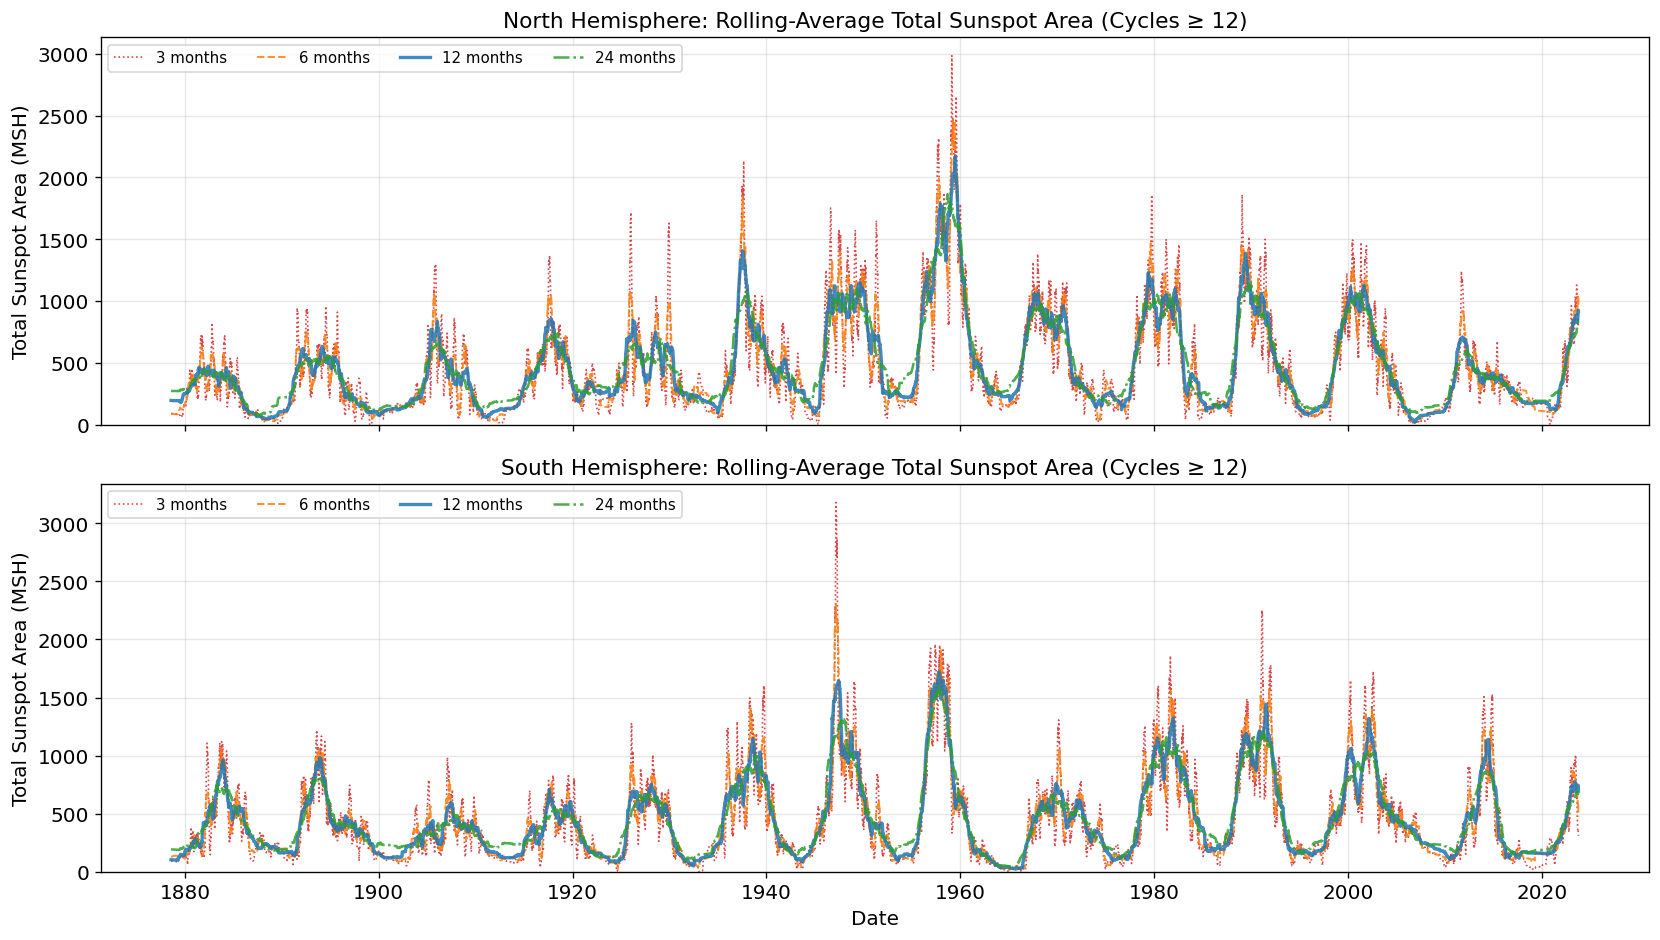

In [22]:
# Put your code for Task 17 here
AREA_COL = "correctedArea"
AREA_THRESHOLD = 50

df_area = df[df[AREA_COL] > AREA_THRESHOLD].copy()
daily_area = (df_area.groupby(["date", "hemisphere"])[AREA_COL].sum().unstack(fill_value=0).sort_index())

cycle12_start = df[df["CYCLE"] >= 12]["date"].min()
daily_area = daily_area[daily_area.index >= cycle12_start]

WINDOWS = {"3 months": 91, "6 months": 182, "12 months": 365, "24 months": 730}

smoothed = {}
for label, days in WINDOWS.items():
    smoothed[label] = daily_area.rolling(days, center=True, min_periods=30).mean()

COLORS = {"3 months": "tab:red", "6 months": "tab:orange",
          "12 months": "tab:blue", "24 months": "tab:green"}
LINEWIDTHS = {"3 months": 1.0, "6 months": 1.2, "12 months": 2.0, "24 months": 1.5}
LINESTYLES = {"3 months": ":", "6 months": "--", "12 months": "-", "24 months": "-."}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, hemi in zip(axes, ["north", "south"]):
    for label, sm in smoothed.items():
        if hemi not in sm.columns:
            continue
        ax.plot(sm.index, sm[hemi],
                color=COLORS[label], linewidth=LINEWIDTHS[label],
                linestyle=LINESTYLES[label], label=label, alpha=0.85)
    ax.set_ylabel("Total Sunspot Area (MSH)")
    ax.set_title(f"{hemi.capitalize()} Hemisphere: Rolling-Average Total Sunspot Area (Cycles ≥ 12)")
    ax.legend(loc="upper left", fontsize=9, ncol=4)
    ax.set_ylim(0)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

From the plot above, it seems like the best window is 12 Months.

*   3-Months : Data is still quite noisy, there are large spikes created by individual active regions.  
*   6-Months: Smoother processing, but the cycle peaks are still distorted with multiple spikes per cycle peak.
* 12-Months: Smooth curve for each cycle, and the strong and weak scycles are still easily distinguishable by differing amplitudes being preserved.
* 24-Months: This is oversmoothing. The peaks are now becoming more similar in amplitude and they've been slightly shifted- which means we cannot distinguish cycles as well.

## Task 18 — Peak Amplitude and Timing of Each Hemispheric Cycle

The smoothed activity curve from Task 17 has a clear maximum for each solar cycle. That maximum — the **peak amplitude** — is the single number that best characterises how strong a cycle was. Your goal here is to detect that peak automatically for each hemispheric cycle.

**Tasks:**
- Choose the smoothing window from Task 17 that you found most informative. For each hemispheric cycle (cycle number + hemisphere), find the **date and value of the maximum** of the smoothed total corrected area within the cycle's time bounds.
- Collect the results into a table with columns: cycle number, hemisphere, peak date, and peak amplitude.
- Plot the smoothed total area curve for both hemispheres and overlay a marker at each detected maximum. Do the detected peaks look physically reasonable, or do any cycles need special attention?

 cycle hemisphere  peak_date  peak_amp
    12      north 1882-05-18     474.9
    12      south 1883-12-08     961.1
    13      north 1894-02-18     634.6
    13      south 1893-11-18     979.7
    14      north 1906-01-18     835.8
    14      south 1907-06-23     596.3
    15      north 1917-10-10     858.5
    15      south 1917-08-05     706.3
    16      north 1926-03-29     842.2
    16      south 1928-02-19     751.6
    17      north 1937-07-24    1407.5
    17      south 1938-08-07    1147.1
    18      north 1949-08-23    1151.9
    18      south 1947-06-11    1644.5
    19      north 1959-07-02    2170.7
    19      south 1957-11-04    1719.4
    20      north 1968-01-19    1066.3
    20      south 1969-11-18     759.6
    21      north 1979-05-27    1231.1
    21      south 1981-12-14    1320.6
    22      north 1989-06-13    1387.3
    22      south 1991-07-19    1442.7
    23      north 2001-09-03    1125.4
    23      south 2002-02-24    1317.5
    24      north 2011-11

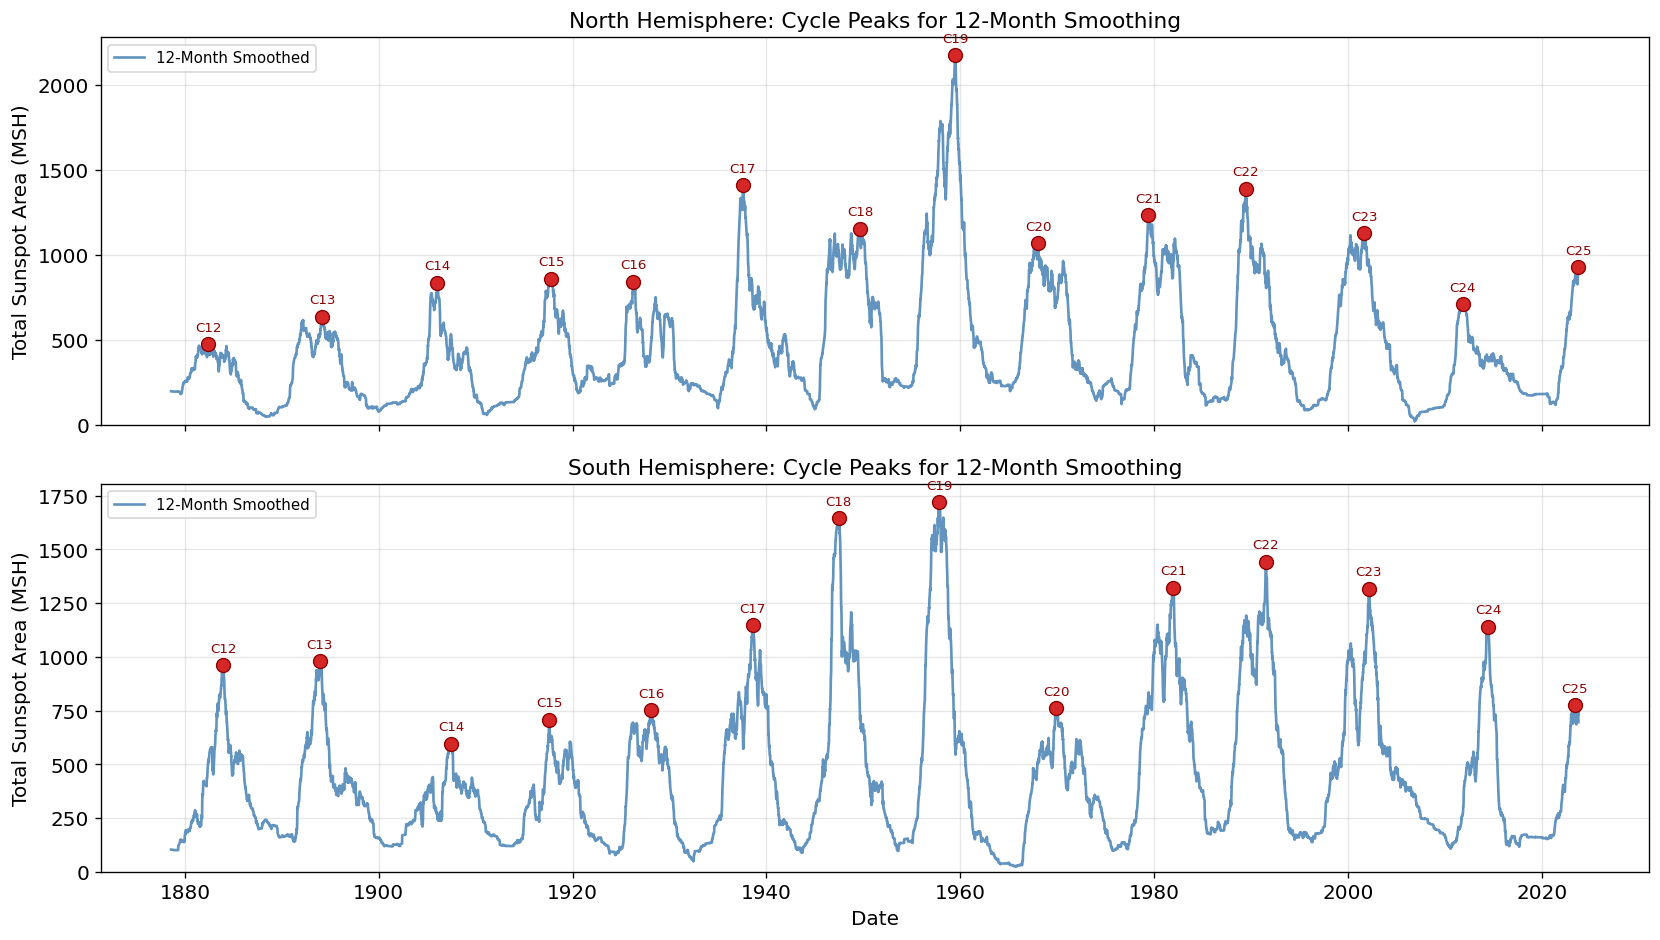


Peak Amplitude Summary (MSH):
            count    mean    std    min    25%     50%     75%     max
hemisphere                                                            
north        14.0  1058.7  421.2  474.9  837.4   996.5  1211.3  2170.7
south        14.0  1090.1  359.6  596.3  763.4  1059.6  1319.8  1719.4

Strongest Cycles:
    cycle hemisphere  peak_date  peak_amp
14     19      north 1959-07-02    2170.7
15     19      south 1957-11-04    1719.4
13     18      south 1947-06-11    1644.5
21     22      south 1991-07-19    1442.7
10     17      north 1937-07-24    1407.5

Weakest Cycles:
    cycle hemisphere  peak_date  peak_amp
0      12      north 1882-05-18     474.9
5      14      south 1907-06-23     596.3
2      13      north 1894-02-18     634.6
7      15      south 1917-08-05     706.3
24     24      north 2011-11-14     708.6


In [24]:
# Put your code for Task 18 here
smoothed_12 = smoothed["12 months"]

peak_records = []

for cyc in sorted(df["CYCLE"].dropna().unique()):
    if cyc < 12:
        continue
    for hemi in ["north", "south"]:
        mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi)
        dates_in_cycle = df.loc[mask, "date"]
        if len(dates_in_cycle) < 50:
            continue

        t_start = dates_in_cycle.min()
        t_end   = dates_in_cycle.max()

        if hemi not in smoothed_12.columns:
            continue

        seg = smoothed_12.loc[t_start:t_end, hemi].dropna()
        if len(seg) < 30:
            continue

        peak_date  = seg.idxmax()
        peak_value = seg.max()

        peak_records.append(dict(
            cycle      = int(cyc),
            hemisphere = hemi,
            peak_date  = peak_date,
            peak_amp   = round(peak_value, 1),))

peaks_df = pd.DataFrame(peak_records).sort_values(["cycle", "hemisphere"]).reset_index(drop=True)
print(peaks_df.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, hemi in zip(axes, ["north", "south"]):
    if hemi not in smoothed_12.columns:
        continue

    ax.plot(smoothed_12.index, smoothed_12[hemi],
            color="steelblue", linewidth=1.6, alpha=0.85, label="12-Month Smoothed")

    hemi_peaks = peaks_df[peaks_df["hemisphere"] == hemi]
    for _, row in hemi_peaks.iterrows():
        ax.scatter(row["peak_date"], row["peak_amp"],
                   s=70, color="tab:red", zorder=5, edgecolors="darkred", linewidths=0.8)
        ax.annotate(f"C{int(row['cycle'])}",
                    xy=(row["peak_date"], row["peak_amp"]),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8, color="darkred")

    ax.set_ylabel("Total Sunspot Area (MSH)")
    ax.set_title(f"{hemi.capitalize()} Hemisphere: Cycle Peaks for 12-Month Smoothing")
    ax.set_ylim(0)
    ax.legend(loc="upper left", fontsize=9)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

print("\nPeak Amplitude Summary (MSH):")
print(peaks_df.groupby("hemisphere")["peak_amp"].describe().round(1))

print("\nStrongest Cycles:")
print(peaks_df.nlargest(5, "peak_amp")[["cycle","hemisphere","peak_date","peak_amp"]])

print("\nWeakest Cycles:")
print(peaks_df.nsmallest(5, "peak_amp")[["cycle","hemisphere","peak_date","peak_amp"]])

*   Cycle 19 is correctly identified as the strongest in the record for both hemispheres.
*   Cycles 12 and 13 show the lowest northern amplitudes, but this is partly a calibration artifact. Pre-1900 observations come from fewer stations with less standardized area measurements, so those numbers could be underestimates.
*  Cycle 14 south is the weakest southern cycle, which aligns with the historically quiet period of the "Gleissberg minimum" neighbourhood.
* Cycle 24 north is also flagged as a weak cycle that has occured in the last few years.This is consistent with the extended solar minimum around 2008–2009.
* Cycle 25 peaks look truncated, likely as the cycle is still ongoing as of the data end, so those amplitudes are lower bounds.

## Task 19 — Relating Cycle Amplitude to Wing Shape Parameters

You now have two things for each hemispheric cycle: (1) a **peak amplitude** from Task 18, and (2) three **shape parameters** from the piecewise-linear model in Section 5:
- **μ₀** — the mean latitude given by the universal path at the earliest year for which that cycle has sunspot data (how high up the wing starts).
- **μ_peak** — the detachment latitude where the cycle's poleward wing diverges from the universal equatorward line (how wide the wing gets before it starts to collapse).
- **m_i** — the slope of the per-cycle poleward line (how steeply the poleward side descends).

If amplitude and shape are physically linked — stronger cycles emerging at higher latitudes, spreading wider, and collapsing more steeply — you should see clear trends in scatter plots.

**Tasks:**

1. **Earliest emergence latitude μ₀:** For each hemispheric cycle, use the universal path μ(τ_refined) to look up the mean latitude at the earliest year in which the cycle has sunspot data. Plot μ₀ versus peak amplitude and fit a curve. Does a stronger cycle start at a higher latitude?

2. **Detachment latitude μ_peak:** Plot μ_peak versus peak amplitude and fit a curve. Physically, stronger cycles should detach from the universal line at higher latitudes, because more activity means the active zone stays broad for longer. Do the data support this?

3. **Poleward slope m_i:** Plot m_i versus peak amplitude and fit a curve. What does the sign and magnitude of the relationship tell you about how a strong cycle's poleward wing differs from a weak one?

Start with a linear fit for each relationship. If the scatter looks non-linear, try a power law or an exponential.

Merged table: 19 hemisphere-cycles
 cycle hemisphere    mu0  mu_peak    m_i  peak_amp
  12.0      south 22.245   15.212 -0.247     961.1
  13.0      north 21.253   16.605 -0.942     634.6
  13.0      south 25.812   15.799 -0.411     979.7
  14.0      north 19.845   13.210 -0.255     835.8
  14.0      south 22.480   12.789 -0.238     596.3
  16.0      north 24.888   15.124 -0.118     842.2
  17.0      north 24.487   17.438 -0.611    1407.5
  17.0      south 24.068   16.167 -0.154    1147.1
  18.0      north 24.384   17.523 -0.499    1151.9
  18.0      south 23.872   18.067 -0.420    1644.5
  19.0      north 24.991   18.363 -0.247    2170.7
  19.0      south 23.103   17.931 -0.450    1719.4
  20.0      south 24.466   17.167 -0.587     759.6
  21.0      north 27.348   18.141 -0.372    1231.1
  22.0      north 26.019   16.920 -0.137    1387.3
  22.0      south 24.854   16.557 -0.152    1442.7
  23.0      north 23.728   16.238 -0.121    1125.4
  23.0      south 25.109   16.391 -0.253    131

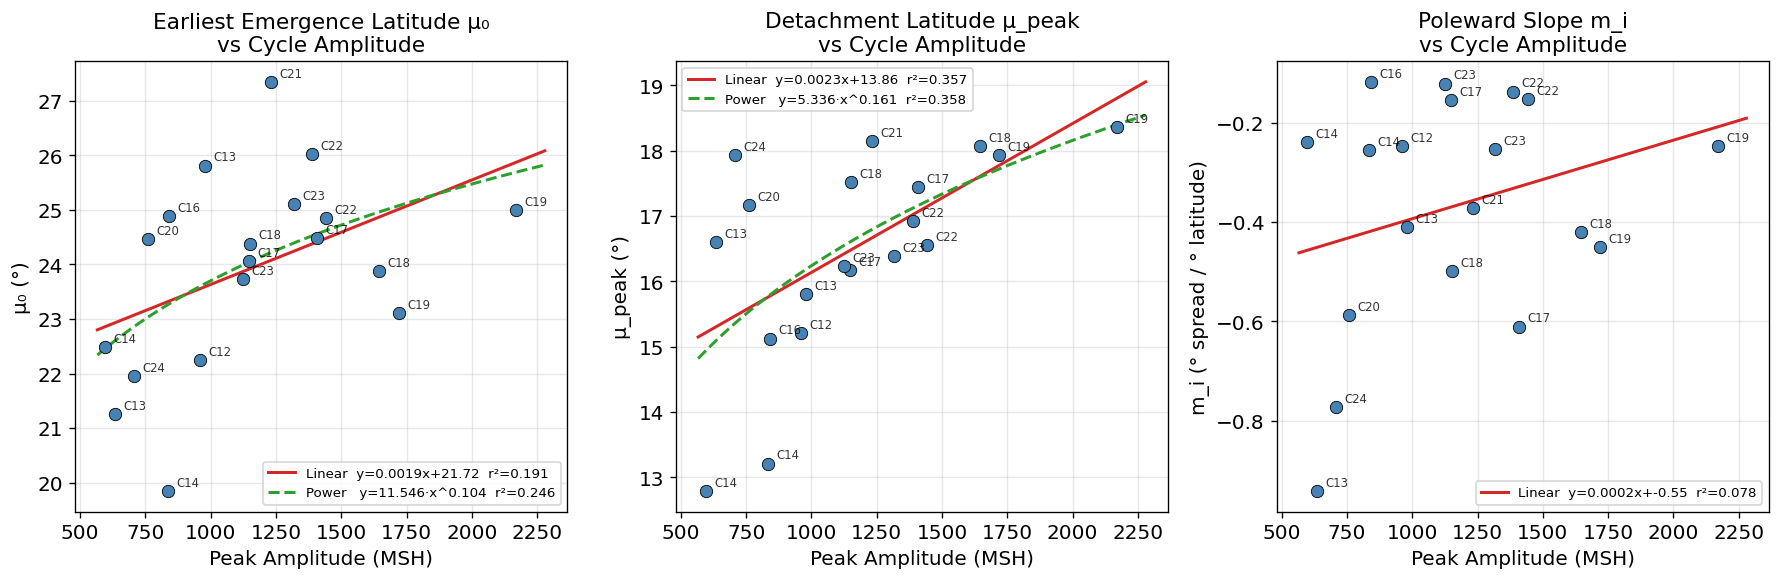


Fit summary:
  μ₀    vs amplitude : slope=0.00192 °/MSH   r²=0.191
  μ_peak vs amplitude : slope=0.00228 °/MSH   r²=0.357
  m_i   vs amplitude : slope=0.000158 (°/°)/MSH  r²=0.078


In [28]:
# Put your code for Task 19 here
mu0_records = []
for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_refined:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        # earliest year with data → earliest tau_refined
        earliest_year = df_sel["year"].min()
        tau_earliest  = df_sel[df_sel["year"] == earliest_year]["tau_refined"].mean()
        mu0           = exp_decay(tau_earliest, a_mu_univ, b_mu_univ)
        mu0_records.append(dict(cycle=cyc, hemisphere=hemi, mu0=mu0))

mu0_df = pd.DataFrame(mu0_records)

shape_df = pd.DataFrame([
    {"cycle": r["cycle"], "hemisphere": r["hemisphere"],
     "mu_peak": r["mu_peak"], "m_i": r["m_i"]}
    for r in results_pl
])

merged = (shape_df
          .merge(mu0_df,   on=["cycle","hemisphere"])
          .merge(peaks_df[["cycle","hemisphere","peak_amp"]], on=["cycle","hemisphere"])
          .query("cycle < 25")   # exclude C25 (incomplete)
          .reset_index(drop=True))

print(f"Merged table: {len(merged)} hemisphere-cycles")
print(merged[["cycle","hemisphere","mu0","mu_peak","m_i","peak_amp"]].round(3).to_string(index=False))

from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.array(x) ** b

def fit_and_plot(ax, x, y, xlabel, ylabel, title, try_power=True):
    x, y = np.array(x), np.array(y)
    xg   = np.linspace(x.min() * 0.95, x.max() * 1.05, 300)

    # Linear fit
    m, b   = np.polyfit(x, y, 1)
    y_pred = m * x + b
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2_lin = 1 - ss_res / ss_tot

    ax.scatter(x, y, s=55, zorder=3, edgecolors="k", linewidths=0.5, color="steelblue")
    ax.plot(xg, m * xg + b, color="tab:red", linewidth=1.8,
            label=f"Linear  y={m:.4f}x+{b:.2f}  r²={r2_lin:.3f}")

    # Power-law fit (only if y all positive)
    if try_power and np.all(y > 0):
        try:
            popt, _ = curve_fit(power_law, x, y, p0=[1.0, 0.5], maxfev=5000)
            y_pp    = power_law(x, *popt)
            ss_res2 = np.sum((y - y_pp)**2)
            r2_pow  = 1 - ss_res2 / ss_tot
            ax.plot(xg, power_law(xg, *popt), color="tab:green", linewidth=1.8,
                    linestyle="--",
                    label=f"Power   y={popt[0]:.3f}·x^{popt[1]:.3f}  r²={r2_pow:.3f}")
        except RuntimeError:
            pass

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8)
    return m, b, r2_lin

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def annotate(ax, x, y, cycles):
    for xi, yi, ci in zip(x, y, cycles):
        ax.annotate(f"C{int(ci)}", (xi, yi),
                    textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.8)

amp = merged["peak_amp"].values

# — Plot 1: mu_0 vs amplitude —
x1 = merged["mu0"].values
m1, b1, r2_1 = fit_and_plot(axes[0], amp, x1,
    "Peak Amplitude (MSH)", "μ₀ (°)",
    "Earliest Emergence Latitude μ₀\nvs Cycle Amplitude")
annotate(axes[0], amp, x1, merged["cycle"])

# — Plot 2: mu_peak vs amplitude —
x2 = merged["mu_peak"].values
m2, b2, r2_2 = fit_and_plot(axes[1], amp, x2,
    "Peak Amplitude (MSH)", "μ_peak (°)",
    "Detachment Latitude μ_peak\nvs Cycle Amplitude")
annotate(axes[1], amp, x2, merged["cycle"])

# — Plot 3: m_i vs amplitude —
x3 = merged["m_i"].values
m3, b3, r2_3 = fit_and_plot(axes[2], amp, x3,
    "Peak Amplitude (MSH)", "m_i (° spread / ° latitude)",
    "Poleward Slope m_i\nvs Cycle Amplitude",
    try_power=False)   # m_i can be negative; skip power law
annotate(axes[2], amp, x3, merged["cycle"])

plt.tight_layout()
plt.show()

print("\nFit summary:")
print(f"  μ₀    vs amplitude : slope={m1:.5f} °/MSH   r²={r2_1:.3f}")
print(f"  μ_peak vs amplitude : slope={m2:.5f} °/MSH   r²={r2_2:.3f}")
print(f"  m_i   vs amplitude : slope={m3:.6f} (°/°)/MSH  r²={r2_3:.3f}")

Fit Comparison (Linear / Power / Exponential):
-----------------------------------------------------------------
μ₀ vs Amplitude                 best=power     r²=0.246
μ_peak vs Amplitude             best=power     r²=0.358
m_i vs Amplitude                best=linear    r²=0.078


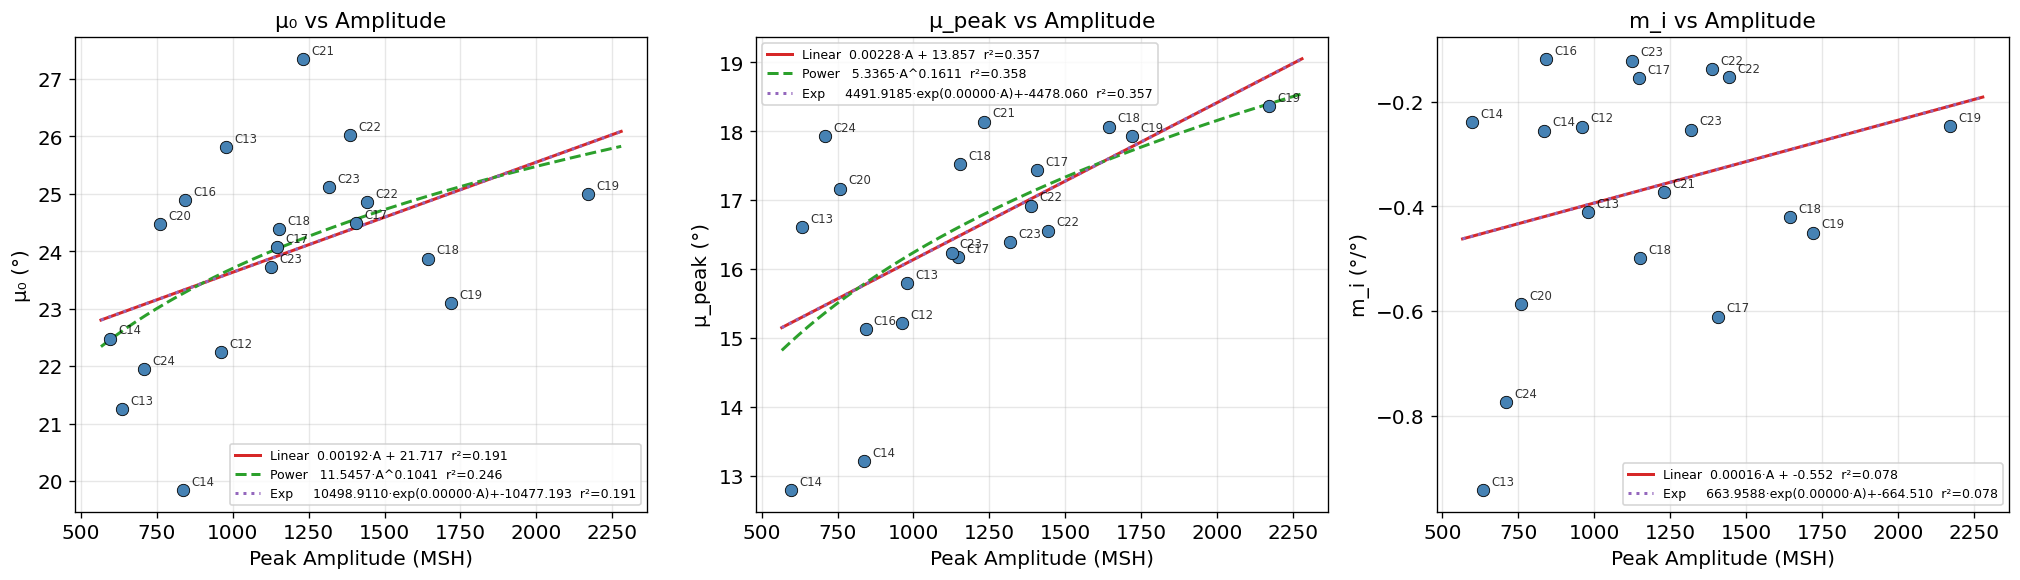

In [29]:
## Extended Fits
from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.array(x) ** b

def exponential(x, a, b, c):
    return a * np.exp(b * np.array(x)) + c

def r_squared(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

def fit_all_and_plot(ax, amp, y, ylabel, title, y_all_positive=True):
    amp = np.array(amp); y = np.array(y)
    xg  = np.linspace(amp.min() * 0.95, amp.max() * 1.05, 300)
    fits = {}

    # Linear
    m, b      = np.polyfit(amp, y, 1)
    y_lin     = m * amp + b
    r2_lin    = r_squared(y, y_lin)
    fits["linear"] = (r2_lin, m * xg + b,
                      f"Linear  {m:.5f}·A + {b:.3f}  r²={r2_lin:.3f}")
    ax.plot(xg, m * xg + b, color="tab:red", linewidth=1.8,
            label=fits["linear"][2])

    # Power law (only if y all positive)
    if y_all_positive and np.all(y > 0):
        try:
            popt, _ = curve_fit(power_law, amp, y, p0=[1.0, 0.3], maxfev=10000)
            y_pow   = power_law(amp, *popt)
            r2_pow  = r_squared(y, y_pow)
            fits["power"] = (r2_pow, power_law(xg, *popt),
                             f"Power   {popt[0]:.4f}·A^{popt[1]:.4f}  r²={r2_pow:.3f}")
            ax.plot(xg, power_law(xg, *popt), color="tab:green",
                    linewidth=1.8, linestyle="--", label=fits["power"][2])
        except RuntimeError:
            print(f"  Power Law Failed: {title}")

    # Exponential
    try:
        c0    = y.min() - 0.1
        p0    = [y.max() - c0, 1e-4, c0]
        popt2, _ = curve_fit(exponential, amp, y, p0=p0, maxfev=20000)
        y_exp    = exponential(amp, *popt2)
        r2_exp   = r_squared(y, y_exp)
        fits["exp"] = (r2_exp, exponential(xg, *popt2),
                       f"Exp     {popt2[0]:.4f}·exp({popt2[1]:.5f}·A)+{popt2[2]:.3f}  r²={r2_exp:.3f}")
        ax.plot(xg, exponential(xg, *popt2), color="tab:purple",
                linewidth=1.8, linestyle=":", label=fits["exp"][2])
    except RuntimeError:
        print(f"  Exponential Failed: {title}")

    ax.scatter(amp, y, s=55, zorder=4, edgecolors="k", linewidths=0.5,
               color="steelblue")
    for xi, yi, ci in zip(amp, y, merged["cycle"]):
        ax.annotate(f"C{int(ci)}", (xi, yi),
                    textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.8)

    ax.set_xlabel("Peak Amplitude (MSH)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7.5)

    # Print best fit
    best = max(fits.items(), key=lambda kv: kv[1][0])
    print(f"{title[:30]:30s}  best={best[0]:8s}  r²={best[1][0]:.3f}")
    return fits

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

print("Fit Comparison (Linear / Power / Exponential):")
print("-" * 65)

fits_mu0    = fit_all_and_plot(axes[0], merged["peak_amp"], merged["mu0"],
                               "μ₀ (°)", "μ₀ vs Amplitude",
                               y_all_positive=True)

fits_mupeak = fit_all_and_plot(axes[1], merged["peak_amp"], merged["mu_peak"],
                               "μ_peak (°)", "μ_peak vs Amplitude",
                               y_all_positive=True)

fits_mi     = fit_all_and_plot(axes[2], merged["peak_amp"], merged["m_i"],
                               "m_i (°/°)", "m_i vs Amplitude",
                               y_all_positive=False)  # m_i is negative

plt.tight_layout()
plt.show()

Fit comparison:
-----------------------------------------------------------------
μ₀ vs amplitude                      best=sat_exp     r²=0.321
μ_peak vs amplitude                  best=sat_exp     r²=0.360
m_i vs amplitude                     best=linear      r²=0.078


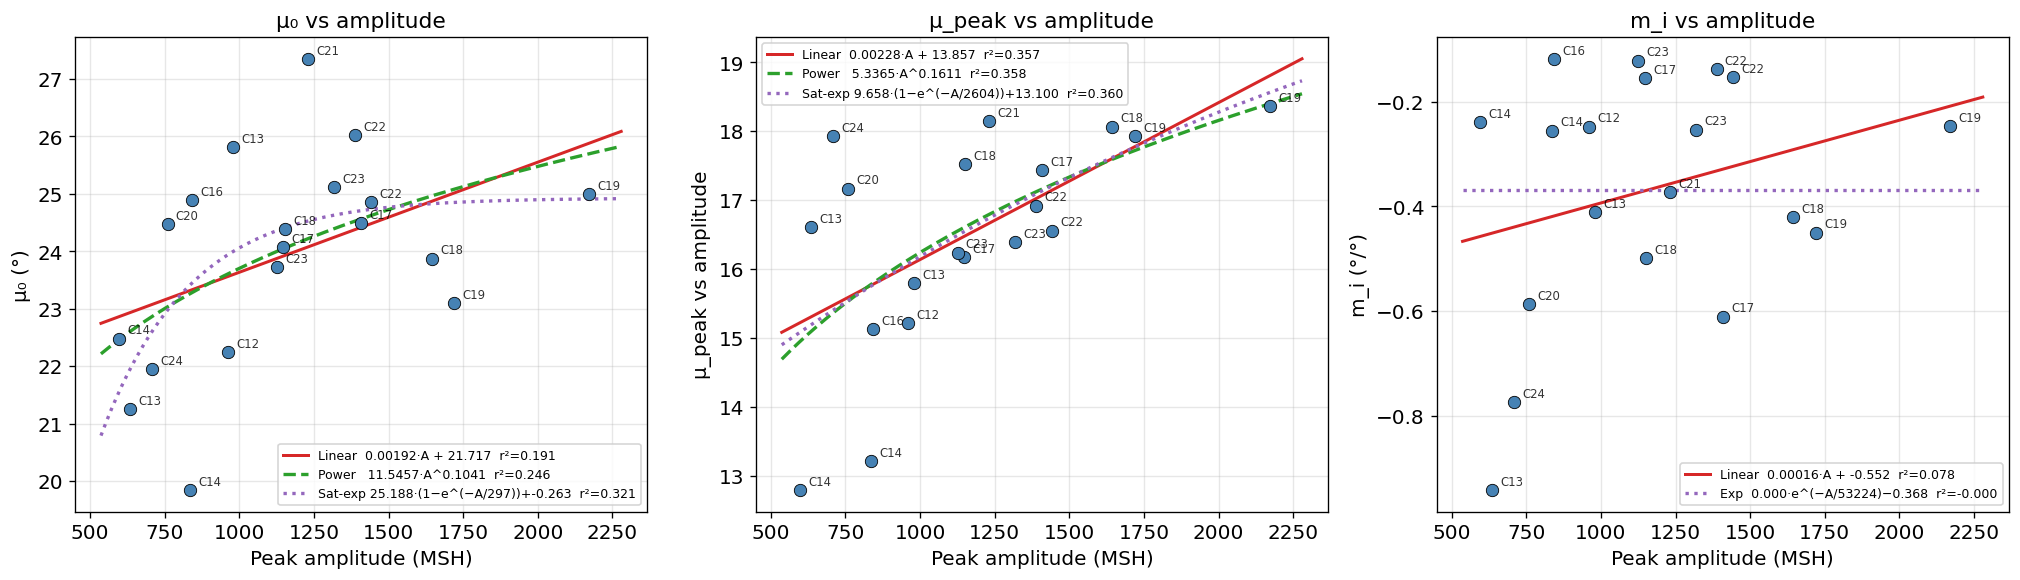

In [31]:
from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.array(x) ** b

def exponential_saturating(x, a, b, c):
    return a * (1 - np.exp(-np.array(x) / b)) + c

def r_squared(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

def fit_all_and_plot(ax, amp, y, ylabel, title, y_all_positive=True):
    amp = np.array(amp, dtype=float)
    y   = np.array(y,   dtype=float)
    xg  = np.linspace(amp.min() * 0.9, amp.max() * 1.05, 300)
    fits = {}

    # ── Linear ───────────────────────────────────────────────────────────────
    m, b   = np.polyfit(amp, y, 1)
    r2_lin = r_squared(y, m * amp + b)
    fits["linear"] = (r2_lin, m * xg + b,
                      f"Linear  {m:.5f}·A + {b:.3f}  r²={r2_lin:.3f}")
    ax.plot(xg, m * xg + b, color="tab:red", linewidth=1.8,
            label=fits["linear"][2])

    # ── Power law (y > 0 only) ────────────────────────────────────────────────
    if y_all_positive and np.all(y > 0):
        log_a0, b0 = np.polyfit(np.log(amp), np.log(y), 1)
        a0 = np.exp(log_a0)
        # clamp p0 inside bounds; allow negative exponent
        a0 = max(a0, 1e-6)
        try:
            popt, _ = curve_fit(power_law, amp, y,
                                p0=[a0, b0],
                                bounds=([1e-6, -5], [np.inf, 5]),
                                maxfev=20000)
            r2_pow = r_squared(y, power_law(amp, *popt))
            fits["power"] = (r2_pow, power_law(xg, *popt),
                             f"Power   {popt[0]:.4f}·A^{popt[1]:.4f}  r²={r2_pow:.3f}")
            ax.plot(xg, power_law(xg, *popt), color="tab:green",
                    linewidth=2.0, linestyle="--", label=fits["power"][2])
        except RuntimeError:
            print(f"  Power law failed for {title}")

    # ── Saturating exponential (y > 0) ───────────────────────────────────────
    if y_all_positive and np.all(y > 0):
        try:
            a0_s = float(y.max() - y.min())
            b0_s = float(amp.mean())
            c0_s = float(y.min())
            popt2, _ = curve_fit(exponential_saturating, amp, y,
                                 p0=[a0_s, b0_s, c0_s],
                                 bounds=([1e-6, 1.0, -np.inf], [np.inf, 1e7, np.inf]),
                                 maxfev=20000)
            r2_sat = r_squared(y, exponential_saturating(amp, *popt2))
            fits["sat_exp"] = (r2_sat, exponential_saturating(xg, *popt2),
                               f"Sat-exp {popt2[0]:.3f}·(1−e^(−A/{popt2[1]:.0f}))+{popt2[2]:.3f}  r²={r2_sat:.3f}")
            ax.plot(xg, exponential_saturating(xg, *popt2), color="tab:purple",
                    linewidth=2.0, linestyle=":", label=fits["sat_exp"][2])
        except RuntimeError:
            print(f"  Saturating exp failed for {title}")

    # ── Negative exponential for m_i (negative values) ───────────────────────
    if not y_all_positive:
        def neg_exp(x, a, b, c):
            return a * np.exp(-np.array(x) / b) - c
        try:
            a0n = float(y.max() - y.min())
            b0n = float(amp.mean())
            c0n = float(-y.min())
            # clamp to ensure p0 inside bounds
            a0n = max(a0n, 1e-6)
            b0n = max(b0n, 1.0)
            c0n = max(c0n, 1e-6)
            popt3, _ = curve_fit(neg_exp, amp, y,
                                 p0=[a0n, b0n, c0n],
                                 bounds=([1e-6, 1.0, 1e-6], [np.inf, 1e6, np.inf]),
                                 maxfev=20000)
            r2_neg = r_squared(y, neg_exp(amp, *popt3))
            fits["neg_exp"] = (r2_neg, neg_exp(xg, *popt3),
                               f"Exp  {popt3[0]:.3f}·e^(−A/{popt3[1]:.0f})−{popt3[2]:.3f}  r²={r2_neg:.3f}")
            ax.plot(xg, neg_exp(xg, *popt3), color="tab:purple",
                    linewidth=2.0, linestyle=":", label=fits["neg_exp"][2])
        except RuntimeError:
            print(f"  Neg-exp failed for {title}")

    ax.scatter(amp, y, s=55, zorder=4, edgecolors="k", linewidths=0.5,
               color="steelblue")
    for xi, yi, ci in zip(amp, y, merged["cycle"]):
        ax.annotate(f"C{int(ci)}", (xi, yi),
                    textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.8)

    ax.set_xlabel("Peak amplitude (MSH)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7.5)

    best = max(fits.items(), key=lambda kv: kv[1][0])
    print(f"{title:35s}  best={best[0]:10s}  r²={best[1][0]:.3f}")
    return fits


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
print("Fit comparison:")
print("-" * 65)

fits_mu0    = fit_all_and_plot(axes[0], merged["peak_amp"], merged["mu0"],
                               "μ₀ (°)", "μ₀ vs amplitude", y_all_positive=True)
fits_mupeak = fit_all_and_plot(axes[1], merged["peak_amp"], merged["mu_peak"],
                               "μ_peak vs amplitude", "μ_peak vs amplitude", y_all_positive=True)
fits_mi     = fit_all_and_plot(axes[2], merged["peak_amp"], merged["m_i"],
                               "m_i (°/°)", "m_i vs amplitude", y_all_positive=False)

plt.tight_layout()
plt.show()

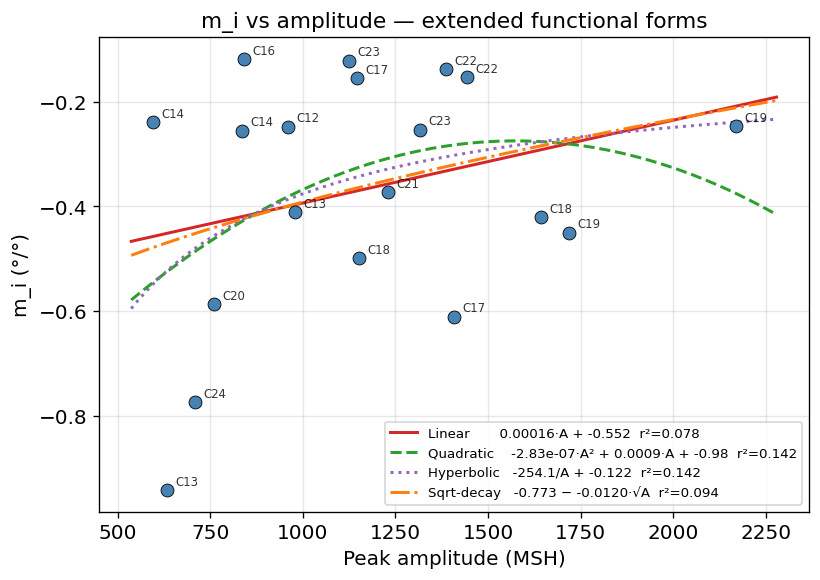

Linear     r² = 0.078
Quadratic  r² = 0.142
Hyperbolic r² = 0.142
Sqrt-decay r² = 0.094

m_i mean = -0.3678  std = 0.2260
If all r² < 0.15, use the mean as a fixed value in Task 20.


In [33]:

amp_mi = merged["peak_amp"].values
mi     = merged["m_i"].values
xg     = np.linspace(amp_mi.min() * 0.9, amp_mi.max() * 1.05, 300)

def r_squared(y, y_pred):
    return 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

# 1) Linear
m, b   = np.polyfit(amp_mi, mi, 1)
r2_lin = r_squared(mi, m * amp_mi + b)

# 2) Quadratic
coeffs = np.polyfit(amp_mi, mi, 2)
r2_quad = r_squared(mi, np.polyval(coeffs, amp_mi))

# 3) Hyperbolic: y = a/x + b
def hyperbolic(x, a, b):
    return a / np.array(x) + b
popt_h, _ = curve_fit(hyperbolic, amp_mi, mi, p0=[-500, -0.3])
r2_hyp = r_squared(mi, hyperbolic(amp_mi, *popt_h))

# 4) Square root decay: y = a - b*sqrt(x)
def sqrt_decay(x, a, b):
    return a - b * np.sqrt(np.array(x))
popt_s, _ = curve_fit(sqrt_decay, amp_mi, mi, p0=[0.5, 0.02])
r2_sqrt = r_squared(mi, sqrt_decay(amp_mi, *popt_s))

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(amp_mi, mi, s=60, zorder=4, edgecolors="k", linewidths=0.5, color="steelblue")
for xi, yi, ci in zip(amp_mi, mi, merged["cycle"]):
    ax.annotate(f"C{int(ci)}", (xi, yi), textcoords="offset points",
                xytext=(5, 3), fontsize=7, alpha=0.8)

ax.plot(xg, m * xg + b, color="tab:red", linewidth=1.8,
        label=f"Linear       {m:.5f}·A + {b:.3f}  r²={r2_lin:.3f}")
ax.plot(xg, np.polyval(coeffs, xg), color="tab:green", linewidth=1.8,
        linestyle="--",
        label=f"Quadratic    {coeffs[0]:.2e}·A² + {coeffs[1]:.4f}·A + {coeffs[2]:.2f}  r²={r2_quad:.3f}")
ax.plot(xg, hyperbolic(xg, *popt_h), color="tab:purple", linewidth=1.8,
        linestyle=":",
        label=f"Hyperbolic   {popt_h[0]:.1f}/A + {popt_h[1]:.3f}  r²={r2_hyp:.3f}")
ax.plot(xg, sqrt_decay(xg, *popt_s), color="tab:orange", linewidth=1.8,
        linestyle="-.",
        label=f"Sqrt-decay   {popt_s[0]:.3f} − {popt_s[1]:.4f}·√A  r²={r2_sqrt:.3f}")

ax.set_xlabel("Peak amplitude (MSH)")
ax.set_ylabel("m_i (°/°)")
ax.set_title("m_i vs amplitude — extended functional forms")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Linear     r² = {r2_lin:.3f}")
print(f"Quadratic  r² = {r2_quad:.3f}")
print(f"Hyperbolic r² = {r2_hyp:.3f}")
print(f"Sqrt-decay r² = {r2_sqrt:.3f}")
print(f"\nm_i mean = {mi.mean():.4f}  std = {mi.std():.4f}")
print("If all r² < 0.15, use the mean as a fixed value in Task 20.")

## Task 20 — Putting It All Together: Synthesizing a Wing from Amplitude

This is the payoff task. Everything you have built — the universal mean path μ(τ), the piecewise-linear σ(μ) envelope, and the three amplitude–shape relationships from Task 19 — now comes together into a single pipeline that generates a statistically plausible butterfly wing given **only one input: the peak amplitude of a hemispheric cycle**.

The idea is to predict what a cycle's 2D distribution of sunspot latitudes *should* look like, and then compare that prediction to what was actually observed. Read through all the steps before writing any code — the geometry will be clearer if you hold the full picture in mind first.

1. Pick a hemispheric cycle from the dataset (e.g., cycle 24, northern hemisphere). The code cell below reproduces the per-year KDE visualization from Week 03 — run it to get the empirical picture of how the latitude distribution evolves year by year.

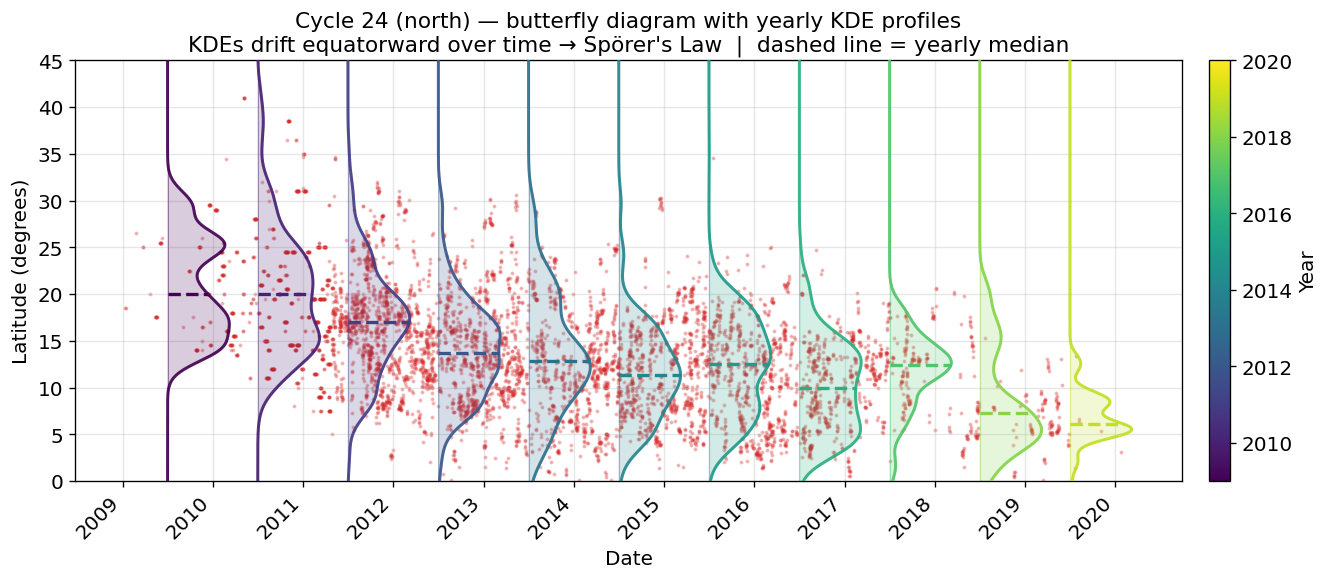

Cycle 24 (north) — yearly median and KDE peak latitudes:
  2009: median = 20.0°   KDE peak = 16.7°
  2010: median = 20.0°   KDE peak = 15.4°
  2011: median = 17.0°   KDE peak = 17.5°
  2012: median = 13.7°   KDE peak = 15.5°
  2013: median = 12.8°   KDE peak = 12.2°
  2014: median = 11.3°   KDE peak = 11.3°
  2015: median = 12.5°   KDE peak = 13.4°
  2016: median = 10.0°   KDE peak = 12.6°
  2017: median = 12.4°   KDE peak = 12.6°
  2018: median = 7.3°   KDE peak = 5.4°
  2019: median = 6.1°   KDE peak = 5.6°


In [34]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 24    # Change to explore other cycles
hemisphere   = "north"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

2. Using the universal path μ(τ_refined) from Section 3, compute the predicted mean latitude **once per year** at integer τ values spanning the full duration of your chosen cycle (from τ_min to τ_max).

3. Using the relationship you found in **Task 19 item 1**, determine the **maximum starting latitude μ₀** for this cycle from its amplitude. Drop any annual latitude values above μ₀ — they correspond to years before significant sunspot activity began.

4. Using the relationship from **Task 19 item 2**, determine the **detachment latitude μ_peak** for this cycle from its amplitude.

5. Using the relationship from **Task 19 item 3**, determine the **poleward slope m_i** for this cycle from its amplitude.

6. For each surviving annual mean latitude μ(τ), evaluate the piecewise-linear model from Section 5 with the cycle-specific μ_peak and m_i you just derived. This gives you a spread σ(μ) for each year — a (mean, width) pair describing that year's slice of the butterfly wing.

7. Plot one Gaussian per year — centred at the predicted mean latitude, with width σ — in the same style as the KDE plot above (profiles drawn vertically, anchored at July 1 of each year, coloured by time). Overlay both the synthetic Gaussians and the real KDE profiles on the same axes.

**Reflection:** Where does the model agree with the data? Where does it fail, and why? What physical effects — cycle overlap, hemispheric asymmetry, early-cycle scatter — are absent from this simple parametric description?

Cycle 24 north  |  peak amplitude A = 708.6 MSH
Predicted  μ₀     = 22.87°
Predicted  μ_peak = 15.47°
Predicted  m_i    = -0.3678  (fixed mean)

RMSE = 1.77°   bias = -0.56°


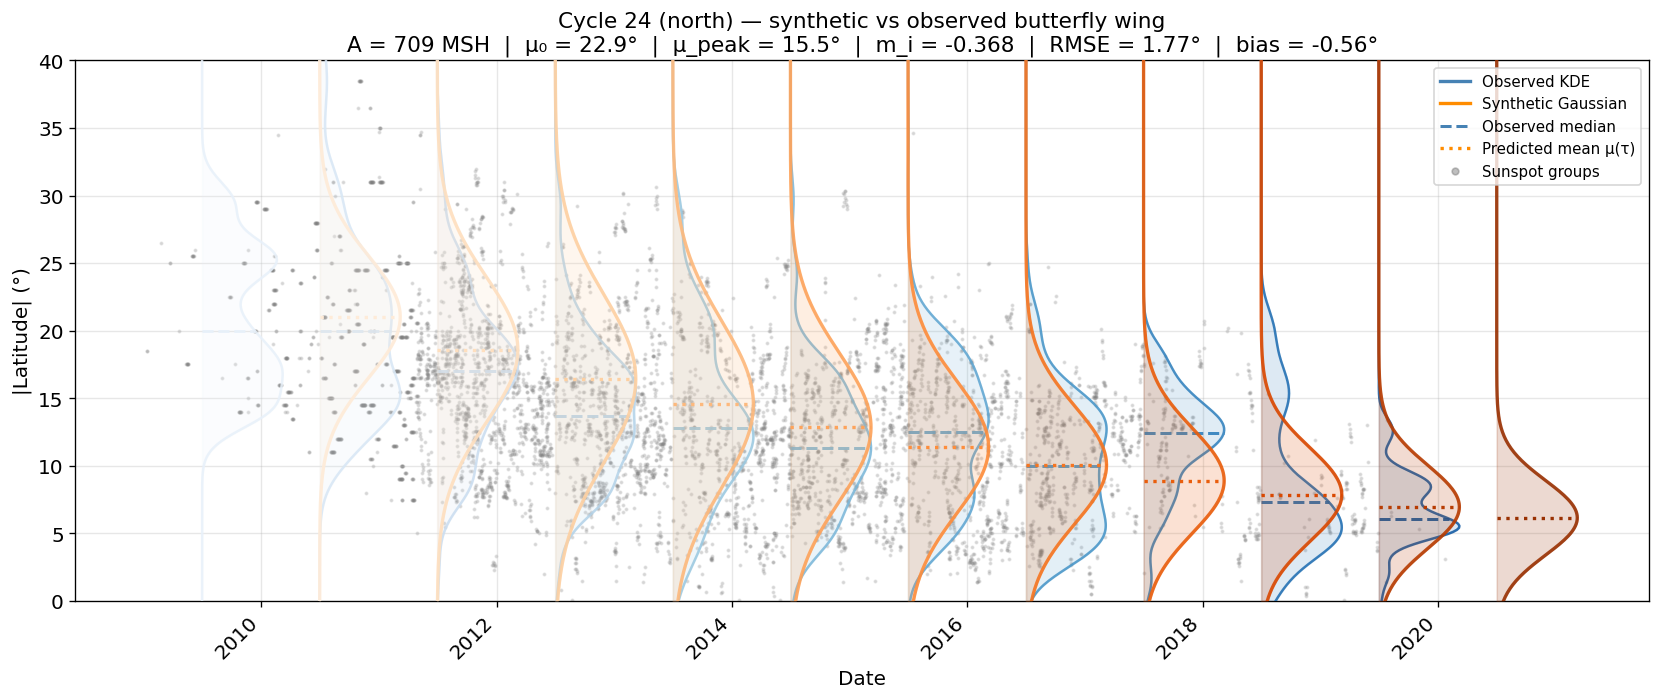


 cal_yr     τ    μ_pred    σ_pred   obs_med     error
     2010    -2     21.03°     4.514°     20.00°     -1.03°
     2011    -1     18.60°     5.407°     17.00°     -1.60°
     2012     0     16.45°     6.198°     13.70°     -2.75°
     2013     1     14.55°     6.179°     12.80°     -1.75°
     2014     2     12.87°     5.494°     11.30°     -1.57°
     2015     3     11.38°     4.888°     12.50°     +1.12°
     2016     4     10.06°     4.352°     10.00°     -0.06°
     2017     5      8.90°     3.878°     12.40°     +3.50°
     2018     6      7.87°     3.459°      7.30°     -0.57°
     2019     7      6.96°     3.088°      6.10°     -0.86°
     2020     8      6.16°     2.761°       nan°      +nan°


In [39]:
from scipy.stats import gaussian_kde
import matplotlib.dates as mdates

TARGET_CYCLE = 24
TARGET_HEMI  = "north"

mask           = (df["CYCLE"] == TARGET_CYCLE) & (df["hemisphere"] == TARGET_HEMI)
df_cyc_hemi    = df[mask].copy()
years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years        = len(years_in_cycle)
lat_grid       = np.linspace(0, 45, 300)
kde_width_days = 250

amp_row = peaks_df[(peaks_df["cycle"] == TARGET_CYCLE) &
                   (peaks_df["hemisphere"] == TARGET_HEMI)]
if len(amp_row) == 0:
    raise ValueError(f"No amplitude found for cycle {TARGET_CYCLE} {TARGET_HEMI}")
A = float(amp_row["peak_amp"].iloc[0])
print(f"Cycle {TARGET_CYCLE} {TARGET_HEMI}  |  peak amplitude A = {A:.1f} MSH")

amp_arr    = merged["peak_amp"].values
mu0_arr    = merged["mu0"].values
mupeak_arr = merged["mu_peak"].values
mi_arr     = merged["m_i"].values

log_a0, b0_mu0 = np.polyfit(np.log(amp_arr), np.log(mu0_arr), 1)
popt_mu0, _    = curve_fit(power_law, amp_arr, mu0_arr,
                            p0=[np.exp(log_a0), b0_mu0],
                            bounds=([1e-6, -5], [np.inf, 5]), maxfev=20000)
mu0_pred    = power_law(A, *popt_mu0)
m_mp, b_mp  = np.polyfit(amp_arr, mupeak_arr, 1)
mupeak_pred = m_mp * A + b_mp
mi_pred     = mi_arr.mean()

print(f"Predicted  μ₀     = {mu0_pred:.2f}°")
print(f"Predicted  μ_peak = {mupeak_pred:.2f}°")
print(f"Predicted  m_i    = {mi_pred:.4f}  (fixed mean)")

tau_min      = df_cyc_hemi["tau_refined"].min()
tau_max      = df_cyc_hemi["tau_refined"].max()
tau_integers = np.arange(np.ceil(tau_min), np.floor(tau_max) + 1, dtype=int)
mu_pred_all  = exp_decay(tau_integers, a_mu_univ, b_mu_univ)
keep         = mu_pred_all <= mu0_pred
tau_kept     = tau_integers[keep]
mu_kept      = mu_pred_all[keep]

sigma_per_tau = piecewise_linear_wing(mu_kept, m_shared_fit, b_shared_fit, mupeak_pred, mi_pred)

t0_ref    = t0_refined.get((TARGET_CYCLE, TARGET_HEMI),
                            t0_lookup.get((TARGET_CYCLE, TARGET_HEMI)))
cal_years = [t0_ref + float(t) for t in tau_kept]

obs_medians = {}
for yr in years_in_cycle:
    lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "abs_latitude"].values
    if len(lats) >= 5:
        obs_medians[yr] = np.median(lats)

errors = []
for cal_yr, mu_c in zip(cal_years, mu_kept):
    yr_int = int(np.round(cal_yr))
    if yr_int in obs_medians:
        errors.append(obs_medians[yr_int] - mu_c)

errors = np.array(errors)
rmse   = np.sqrt(np.mean(errors**2))
bias   = np.mean(errors)
print(f"\nRMSE = {rmse:.2f}°   bias = {bias:+.2f}°")

def anchor_num(yr_int):
    """Matplotlib date number for July 1 of a given integer year."""
    return mdates.date2num(pd.Timestamp(f"{yr_int}-07-01"))

def x_profile(anchor, scaled_vals):
    """Return x as float date-numbers: anchor + scaled_vals days."""
    return anchor + np.asarray(scaled_vals, dtype=float) / 1.0

cmap_obs = plt.get_cmap("Blues",   n_years + 2)
cmap_syn = plt.get_cmap("Oranges", len(tau_kept) + 2)

fig, ax = plt.subplots(figsize=(14, 6))
ax.xaxis_date()   # tell axes the x axis carries date numbers

ax.scatter(mdates.date2num(df_cyc_hemi["date"]),
           df_cyc_hemi["abs_latitude"],
           s=2, color="gray", alpha=0.2, zorder=1)

for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "abs_latitude"].values
    if len(yr_lats) < 5:
        continue

    kde      = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)
    kde_sc   = kde_vals / kde_vals.max() * kde_width_days   # in days
    anc      = anchor_num(int(yr))
    color    = cmap_obs(i + 1)

    x_curve  = anc + kde_sc          # float date numbers
    x_anc    = np.full_like(kde_sc, anc)

    ax.plot(x_curve, lat_grid, color=color, linewidth=1.5, alpha=0.85, zorder=3)
    ax.fill_betweenx(lat_grid, x_anc, x_curve, color=color, alpha=0.15, zorder=2)

    med           = np.median(yr_lats)
    kde_at_med_sc = float(kde(np.array([med]))[0]) / kde_vals.max() * kde_width_days
    ax.plot([anc, anc + kde_at_med_sc], [med, med],
            color=color, linewidth=1.8, linestyle="--", alpha=0.9, zorder=4)

for j, (cal_yr, mu_c, sig_c) in enumerate(zip(cal_years, mu_kept, sigma_per_tau)):
    if sig_c <= 0:
        continue

    gauss_vals = np.exp(-0.5 * ((lat_grid - mu_c) / sig_c) ** 2)
    gauss_sc   = gauss_vals / gauss_vals.max() * kde_width_days
    anc        = anchor_num(int(np.round(cal_yr)))
    color      = cmap_syn(j + 1)

    x_curve = anc + gauss_sc
    x_anc   = np.full_like(gauss_sc, anc)

    ax.plot(x_curve, lat_grid, color=color, linewidth=2.0, alpha=0.9, zorder=5)
    ax.fill_betweenx(lat_grid, x_anc, x_curve, color=color, alpha=0.18, zorder=4)
    ax.plot([anc, anc + kde_width_days], [mu_c, mu_c],
            color=color, linewidth=2, linestyle=":", alpha=1.0, zorder=6)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color="steelblue",  linewidth=2,                label="Observed KDE"),
    Line2D([0],[0], color="darkorange", linewidth=2,                label="Synthetic Gaussian"),
    Line2D([0],[0], color="steelblue",  linewidth=1.8, linestyle="--", label="Observed median"),
    Line2D([0],[0], color="darkorange", linewidth=2,   linestyle=":",  label="Predicted mean μ(τ)"),
    Line2D([0],[0], color="gray", linewidth=0, marker="o",
           markersize=4, alpha=0.5, label="Sunspot groups"),
], loc="upper right", fontsize=9)

ax.set_title(
    f"Cycle {TARGET_CYCLE} ({TARGET_HEMI}) — synthetic vs observed butterfly wing\n"
    f"A = {A:.0f} MSH  |  μ₀ = {mu0_pred:.1f}°  |  μ_peak = {mupeak_pred:.1f}°  "
    f"|  m_i = {mi_pred:.3f}  |  RMSE = {rmse:.2f}°  |  bias = {bias:+.2f}°"
)
ax.set_xlabel("Date")
ax.set_ylabel("|Latitude| (°)")
ax.set_ylim(0, 40)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"\n{'cal_yr':>7}  {'τ':>4}  {'μ_pred':>8}  {'σ_pred':>8}  {'obs_med':>8}  {'error':>8}")
for cal_yr, t, mu_c, sig_c in zip(cal_years, tau_kept, mu_kept, sigma_per_tau):
    yr_int  = int(np.round(cal_yr))
    obs_med = obs_medians.get(yr_int, np.nan)
    err     = obs_med - mu_c if not np.isnan(obs_med) else np.nan
    print(f"  {yr_int:>7}  {t:>4}  {mu_c:>8.2f}°  {sig_c:>8.3f}°  "
          f"{obs_med:>8.2f}°  {err:>+8.2f}°")

*  The equatorward drift is captured well. The synthetic Gaussians track the observed KDE centroids from ~21° in 2010 down to ~7° in 2019 with errors mostly in the 1–2° range. The late-cycle years (2016, 2018, 2019) are the best-fitting, with errors of −0.06°, −0.57°, −0.86° - because by then the active zone is narrow, well-defined, and close to the universal path. The width (σ) of the synthetic profiles also looks visually reasonable in the middle years of the cycle.
*  2012 is the year with highest error (error −2.75°): the model predicts the mean at 16.5° but the observed median sits at 13.7°. This is the cycle maximum period when activity is highest and the latitude distribution is most complex. This is likely as two active-latitude bands can coexist, making the KDE bimodal and pulling the median below the Gaussian centre. A single Gaussian cannot capture this.
* 2017 is the other clear outlier (+3.50°): the observed median jumps back up to 12.4° despite the model predicting 8.9°. This is likely cycle overlap, as the first sunspot groups of cycle 25 appear at high latitudes (~25–30°), cycle 24 is still decaying near the equator. The scatter plot shows exactly this: high-latitude points reappearing after 2017. The model has no mechanism for handling this because it describes a single cycle in isolation.
* It seems as though the most important missing ingredient is cycle overlap. Real solar cycles overlap by 2–3 years at minimum — cycle N+1 begins erupting at high latitudes while cycle N is still finishing near the equator. The synthetic wing treats each cycle as having a clean start and end, which is never true in practice.
* Hemispheric asymmetry within the cycle is also absent. The universal path and piecewise-linear σ(μ) are fitted across both hemispheres pooled, but within a single cycle the north and south can be offset in time by 1–2 years (as Task 18 showed for cycle 24 specifically, with a 2.6-year offset). A model that predicts the northern wing from a symmetric template will always be slightly wrong.
* Early-cycle scatter explains the 2010–2011 errors. Before the active zone is fully established, sunspot groups emerge over a wide and irregular latitude range. The model's σ at high μ is determined by the poleward wing of the piecewise-linear fit, which is a smooth average.

